In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("Data_Heart Problem_risk.csv")
df

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3385,3385,60,1.0,F,NO,0.0,0.0,0,0,0,261.0,123.5,79.0,29.28,70.0,103.0,0
3386,3386,46,1.0,F,NO,0.0,0.0,0,0,0,199.0,102.0,56.0,21.96,80.0,84.0,0
3387,3387,44,3.0,M,YES,3.0,0.0,0,1,0,352.0,164.0,119.0,28.92,73.0,72.0,1
3388,3388,60,1.0,M,NO,0.0,NaN,0,1,0,191.0,167.0,105.0,23.01,80.0,85.0,0


In [3]:
df.head(10)

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0
5,5,61,3.0,F,NO,0.0,0.0,0,1,0,272.0,182.0,121.0,32.80,85.0,65.0,1
6,6,61,1.0,M,NO,0.0,0.0,0,1,0,238.0,232.0,136.0,24.83,75.0,79.0,0
7,7,36,4.0,M,YES,35.0,0.0,0,0,0,295.0,102.0,68.0,28.15,60.0,63.0,0
8,8,41,2.0,F,YES,20.0,NaN,0,0,0,220.0,126.0,78.0,20.70,86.0,79.0,0
9,9,55,2.0,F,NO,0.0,0.0,0,1,0,326.0,144.0,81.0,25.71,85.0,NaN,0


In [4]:
df["cigsPerDay"].value_counts()

cigsPerDay
0.0     1703
20.0     606
30.0     176
15.0     172
10.0     106
9.0      104
5.0      103
3.0       79
40.0      62
1.0       48
25.0      44
43.0      42
35.0      17
2.0       17
6.0       14
8.0       10
7.0        8
60.0       8
18.0       7
4.0        7
50.0       6
17.0       5
23.0       5
11.0       4
12.0       3
13.0       3
19.0       2
16.0       2
45.0       2
14.0       1
70.0       1
38.0       1
Name: count, dtype: int64

In [5]:
df.loc[df["age"]<=19, "Age_group"] = "Teen"
df.loc[(df["age"]>19) & (df["age"]<=39), "Age_group"] = "Adult"
df.loc[(df["age"]>39) & (df["age"]<=59), "Age_group"] = "Mid-Age-Adult"
df.loc[df["age"]>59, "Age_group"] = "Senior-Citizen"

In [6]:
df.head(15)

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,Age_group
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1,Senior-Citizen
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0,Adult
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0,Mid-Age-Adult
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1,Mid-Age-Adult
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0,Senior-Citizen
5,5,61,3.0,F,NO,0.0,0.0,0,1,0,272.0,182.0,121.0,32.80,85.0,65.0,1,Senior-Citizen
6,6,61,1.0,M,NO,0.0,0.0,0,1,0,238.0,232.0,136.0,24.83,75.0,79.0,0,Senior-Citizen
7,7,36,4.0,M,YES,35.0,0.0,0,0,0,295.0,102.0,68.0,28.15,60.0,63.0,0,Adult
8,8,41,2.0,F,YES,20.0,NaN,0,0,0,220.0,126.0,78.0,20.70,86.0,79.0,0,Mid-Age-Adult
9,9,55,2.0,F,NO,0.0,0.0,0,1,0,326.0,144.0,81.0,25.71,85.0,NaN,0,Mid-Age-Adult


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3390 non-null   int64  
 1   age              3390 non-null   int64  
 2   education        3303 non-null   float64
 3   sex              3390 non-null   object 
 4   is_smoking       3390 non-null   object 
 5   cigsPerDay       3368 non-null   float64
 6   BPMeds           3346 non-null   float64
 7   prevalentStroke  3390 non-null   int64  
 8   prevalentHyp     3390 non-null   int64  
 9   diabetes         3390 non-null   int64  
 10  totChol          3352 non-null   float64
 11  sysBP            3390 non-null   float64
 12  diaBP            3390 non-null   float64
 13  BMI              3376 non-null   float64
 14  heartRate        3389 non-null   float64
 15  glucose          3086 non-null   float64
 16  TenYearCHD       3390 non-null   int64  
 17  Age_group     

In [8]:
df.isna().sum()

id                   0
age                  0
education           87
sex                  0
is_smoking           0
cigsPerDay          22
BPMeds              44
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             38
sysBP                0
diaBP                0
BMI                 14
heartRate            1
glucose            304
TenYearCHD           0
Age_group            0
dtype: int64

In [9]:
df.fillna({'education': int(df['education'].mean()),
          'cigsPerDay': int(df['cigsPerDay'].mean()),
          'BPMeds': int(df['BPMeds'].mean()),
          'totChol': int(df['totChol'].mean()),
          'BMI': int(df['BMI'].mean()),
          'glucose': int(df['glucose'].mean()),
          'heartRate': int(df['heartRate'].mean())},inplace=True)
df

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,Age_group
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,25.00,90.0,80.0,1,Senior-Citizen
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0,Adult
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0,Mid-Age-Adult
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1,Mid-Age-Adult
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0,Senior-Citizen
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3385,3385,60,1.0,F,NO,0.0,0.0,0,0,0,261.0,123.5,79.0,29.28,70.0,103.0,0,Senior-Citizen
3386,3386,46,1.0,F,NO,0.0,0.0,0,0,0,199.0,102.0,56.0,21.96,80.0,84.0,0,Mid-Age-Adult
3387,3387,44,3.0,M,YES,3.0,0.0,0,1,0,352.0,164.0,119.0,28.92,73.0,72.0,1,Mid-Age-Adult
3388,3388,60,1.0,M,NO,0.0,0.0,0,1,0,191.0,167.0,105.0,23.01,80.0,85.0,0,Senior-Citizen


In [10]:
df.isnull().sum()

id                 0
age                0
education          0
sex                0
is_smoking         0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
Age_group          0
dtype: int64

In [11]:
df['sex'].value_counts()

sex
F    1923
M    1467
Name: count, dtype: int64

In [12]:
df['is_smoking'].value_counts()

is_smoking
NO     1703
YES    1687
Name: count, dtype: int64

In [13]:
df.loc[(df["heartRate"]<65), "heart_rate_level"] ="Low"
df.loc[(df["heartRate"]>=65)&(df["heartRate"]<=100), "heart_rate_level"] ="Good"
df.loc[(df["heartRate"]>100), "heart_rate_level"] ="high"

In [14]:
df.head(10)

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,Age_group,heart_rate_level
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,25.00,90.0,80.0,1,Senior-Citizen,Good
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0,Adult,Good
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0,Mid-Age-Adult,Good
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1,Mid-Age-Adult,Good
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0,Senior-Citizen,Good
5,5,61,3.0,F,NO,0.0,0.0,0,1,0,272.0,182.0,121.0,32.80,85.0,65.0,1,Senior-Citizen,Good
6,6,61,1.0,M,NO,0.0,0.0,0,1,0,238.0,232.0,136.0,24.83,75.0,79.0,0,Senior-Citizen,Good
7,7,36,4.0,M,YES,35.0,0.0,0,0,0,295.0,102.0,68.0,28.15,60.0,63.0,0,Adult,Low
8,8,41,2.0,F,YES,20.0,0.0,0,0,0,220.0,126.0,78.0,20.70,86.0,79.0,0,Mid-Age-Adult,Good
9,9,55,2.0,F,NO,0.0,0.0,0,1,0,326.0,144.0,81.0,25.71,85.0,82.0,0,Mid-Age-Adult,Good


In [15]:
df.loc[(df["sysBP"]>130), "sys_BP_group"] ="high"
df.loc[(df["sysBP"]<=130)&(df["sysBP"]>120), "sys_BP_group"] ="Near-high"
df.loc[(df["sysBP"]==120), "sys_BP_group"] ="normal"
df.loc[(df["sysBP"]<120)&(df["sysBP"]>=110), "sys_BP_group"] ="Near-normal"
df.loc[(df["sysBP"]<110), "sys_BP_group"] ="low"

In [16]:
df.loc[(df["diaBP"]>85), "dia_BP_group"] ="high"
df.loc[(df["diaBP"]<=85)&(df["diaBP"]>80), "dia_BP_group"] ="Near-high"
df.loc[(df["diaBP"]==80), "dia_BP_group"] ="normal"
df.loc[(df["diaBP"]<80)&(df["diaBP"]>=75), "dia_BP_group"] ="Near-normal"
df.loc[(df["diaBP"]<75), "dia_BP_group"] ="low"

In [17]:
df.head(10)

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,...,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,Age_group,heart_rate_level,sys_BP_group,dia_BP_group
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,...,148.0,85.0,25.00,90.0,80.0,1,Senior-Citizen,Good,high,Near-high
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,...,168.0,98.0,29.77,72.0,75.0,0,Adult,Good,high,high
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,...,116.0,71.0,20.35,88.0,94.0,0,Mid-Age-Adult,Good,Near-normal,low
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,...,158.0,88.0,28.26,68.0,94.0,1,Mid-Age-Adult,Good,high,high
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,...,136.5,85.0,26.42,70.0,77.0,0,Senior-Citizen,Good,high,Near-high
5,5,61,3.0,F,NO,0.0,0.0,0,1,0,...,182.0,121.0,32.80,85.0,65.0,1,Senior-Citizen,Good,high,high
6,6,61,1.0,M,NO,0.0,0.0,0,1,0,...,232.0,136.0,24.83,75.0,79.0,0,Senior-Citizen,Good,high,high
7,7,36,4.0,M,YES,35.0,0.0,0,0,0,...,102.0,68.0,28.15,60.0,63.0,0,Adult,Low,low,low
8,8,41,2.0,F,YES,20.0,0.0,0,0,0,...,126.0,78.0,20.70,86.0,79.0,0,Mid-Age-Adult,Good,Near-high,Near-normal
9,9,55,2.0,F,NO,0.0,0.0,0,1,0,...,144.0,81.0,25.71,85.0,82.0,0,Mid-Age-Adult,Good,high,Near-high


In [18]:
df.loc[(df["glucose"]>=200), "Glucose-level"] ="Danger"
df.loc[(df["glucose"]<=199)&(df["glucose"]>=126), "Glucose-level"] ="Diabetes"
df.loc[(df["glucose"]<=125)&(df["glucose"]>=100), "Glucose-level"] ="Pre-diabetes"
df.loc[(df["glucose"]<=99)&(df["glucose"]>=70), "Glucose-level"] ="normal"
df.loc[(df["glucose"]<70), "Glucose-level"] ="low"

In [19]:
df.head(10)

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,...,diaBP,BMI,heartRate,glucose,TenYearCHD,Age_group,heart_rate_level,sys_BP_group,dia_BP_group,Glucose-level
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,...,85.0,25.00,90.0,80.0,1,Senior-Citizen,Good,high,Near-high,normal
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,...,98.0,29.77,72.0,75.0,0,Adult,Good,high,high,normal
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,...,71.0,20.35,88.0,94.0,0,Mid-Age-Adult,Good,Near-normal,low,normal
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,...,88.0,28.26,68.0,94.0,1,Mid-Age-Adult,Good,high,high,normal
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,...,85.0,26.42,70.0,77.0,0,Senior-Citizen,Good,high,Near-high,normal
5,5,61,3.0,F,NO,0.0,0.0,0,1,0,...,121.0,32.80,85.0,65.0,1,Senior-Citizen,Good,high,high,low
6,6,61,1.0,M,NO,0.0,0.0,0,1,0,...,136.0,24.83,75.0,79.0,0,Senior-Citizen,Good,high,high,normal
7,7,36,4.0,M,YES,35.0,0.0,0,0,0,...,68.0,28.15,60.0,63.0,0,Adult,Low,low,low,low
8,8,41,2.0,F,YES,20.0,0.0,0,0,0,...,78.0,20.70,86.0,79.0,0,Mid-Age-Adult,Good,Near-high,Near-normal,normal
9,9,55,2.0,F,NO,0.0,0.0,0,1,0,...,81.0,25.71,85.0,82.0,0,Mid-Age-Adult,Good,high,Near-high,normal


In [20]:
df.loc[(df["totChol"]<200), "Chol-range"] ="Healthy"
df.loc[(df["totChol"]>=200)&(df["totChol"]<=239), "Chol-range"] ="At-Risk"
df.loc[(df["totChol"]>=240), "Chol-range"] ="Dangerous"

In [21]:
df.loc[(df["BMI"]>30), "BMI-range"] ="Obese"
df.loc[(df["BMI"]<=30)&(df["BMI"]>=25), "BMI-range"] ="Over-weight"
df.loc[(df["BMI"]<25), "BMI-range"] ="Normal"

In [22]:
df.head()

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,...,heartRate,glucose,TenYearCHD,Age_group,heart_rate_level,sys_BP_group,dia_BP_group,Glucose-level,Chol-range,BMI-range
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,...,90.0,80.0,1,Senior-Citizen,Good,high,Near-high,normal,At-Risk,Over-weight
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,...,72.0,75.0,0,Adult,Good,high,high,normal,At-Risk,Over-weight
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,...,88.0,94.0,0,Mid-Age-Adult,Good,Near-normal,low,normal,Dangerous,Normal
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,...,68.0,94.0,1,Mid-Age-Adult,Good,high,high,normal,At-Risk,Over-weight
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,...,70.0,77.0,0,Senior-Citizen,Good,high,Near-high,normal,Dangerous,Over-weight


# Exploratory-Analysis 

In [23]:
def count_plot(b):
    sell=sns.countplot(x=b, palette = 'dark:salmon_r')
    for container in sell.containers:
        sell.bar_label(container)

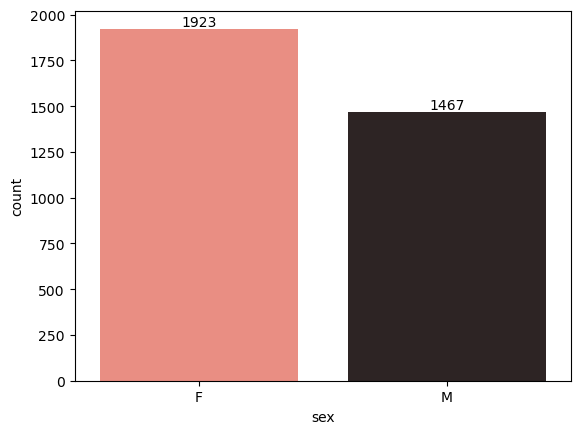

In [24]:
count_plot(df['sex'])

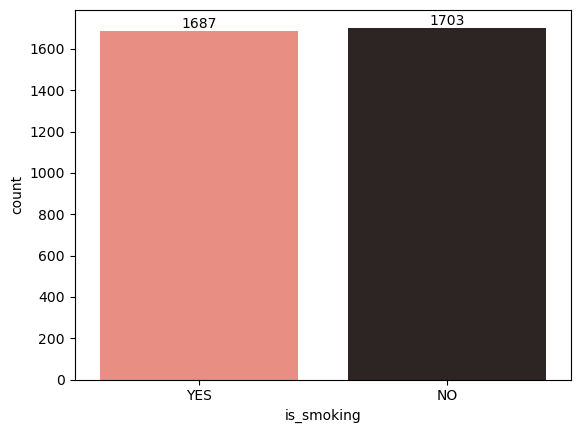

In [25]:
count_plot(df['is_smoking'])

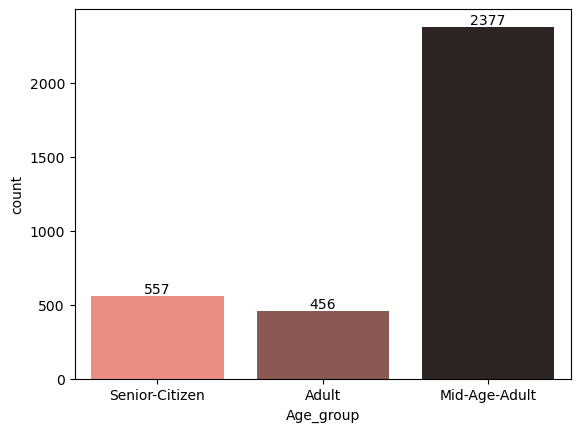

In [26]:
count_plot(df['Age_group'])

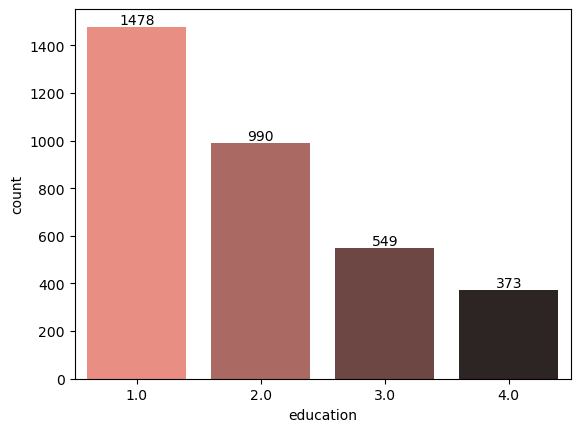

In [27]:
count_plot(df['education'])

<Axes: xlabel='diaBP', ylabel='Count'>

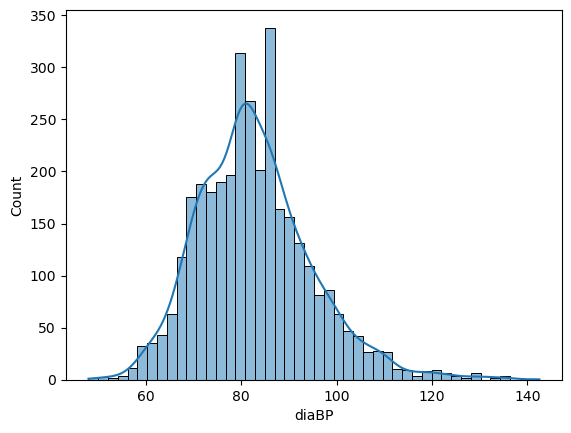

In [28]:
sns.histplot(x=df['diaBP'],kde=True)

<Axes: xlabel='sysBP', ylabel='Count'>

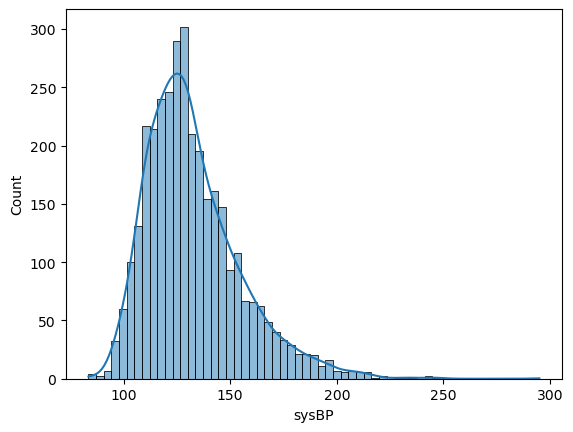

In [29]:
sns.histplot(x=df['sysBP'], kde=True)

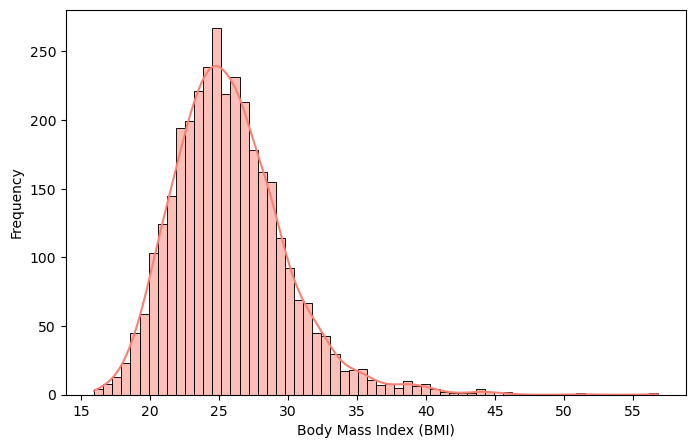

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df['BMI'],kde=True, color='salmon')
plt.xlabel("Body Mass Index (BMI)")
plt.ylabel("Frequency")
plt.show()


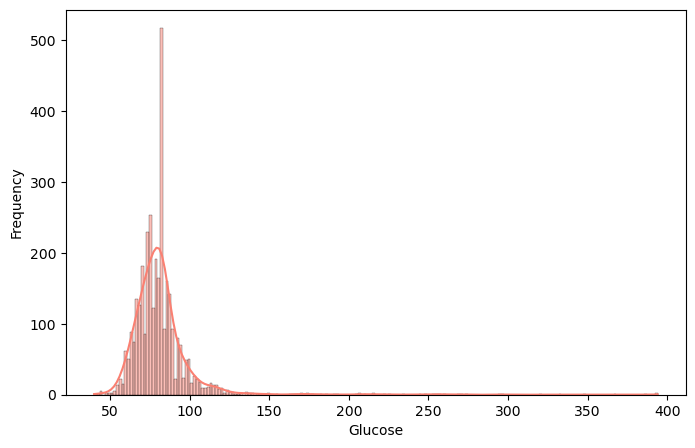

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df['glucose'], kde=True, color='salmon')
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()

# Risk-Factor Analysis

In [32]:
def count_plot(a):
    xyz=sns.countplot(x=a, hue=df['TenYearCHD'], palette = "dark:salmon_r")
    for container in xyz.containers:
        xyz.bar_label(container)

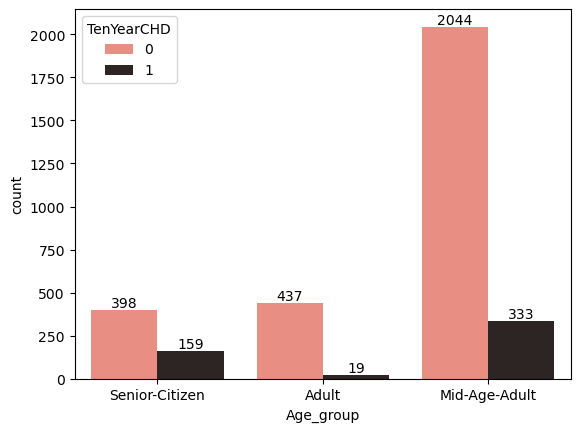

In [33]:
count_plot(df['Age_group'])

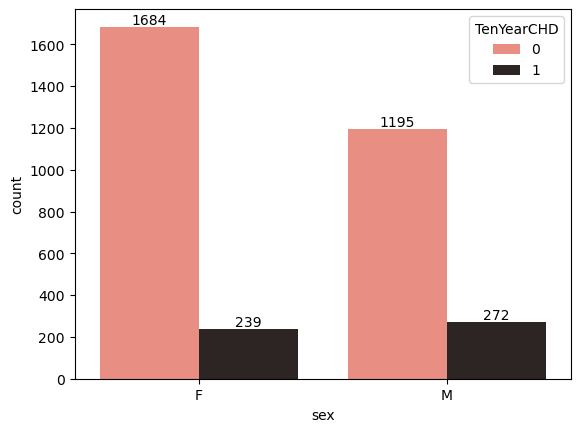

In [34]:
count_plot(df['sex'])

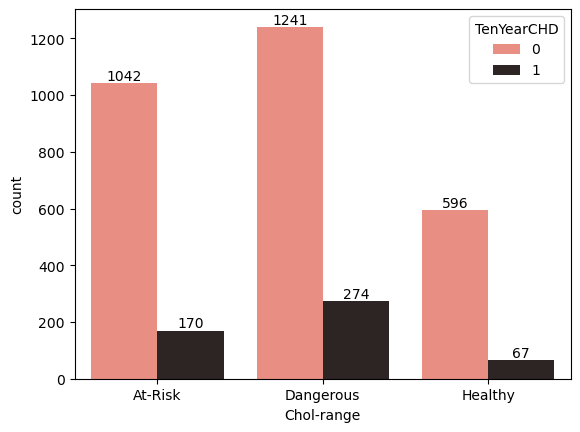

In [35]:
count_plot(df['Chol-range'])

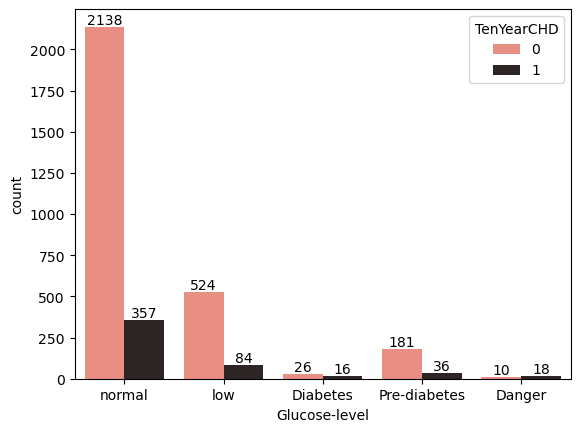

In [36]:
count_plot(df['Glucose-level'])

In [37]:
df.columns

Index(['id', 'age', 'education', 'sex', 'is_smoking', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD', 'Age_group',
       'heart_rate_level', 'sys_BP_group', 'dia_BP_group', 'Glucose-level',
       'Chol-range', 'BMI-range'],
      dtype='object')

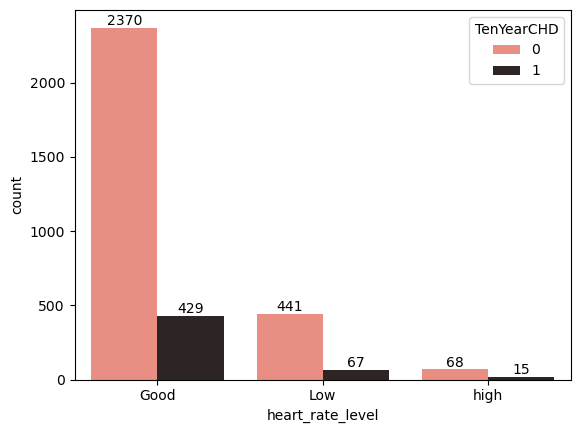

In [38]:
count_plot(df['heart_rate_level'])

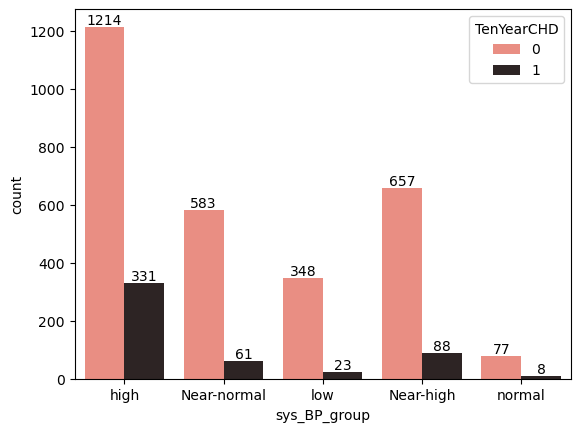

In [39]:
count_plot(df['sys_BP_group'])

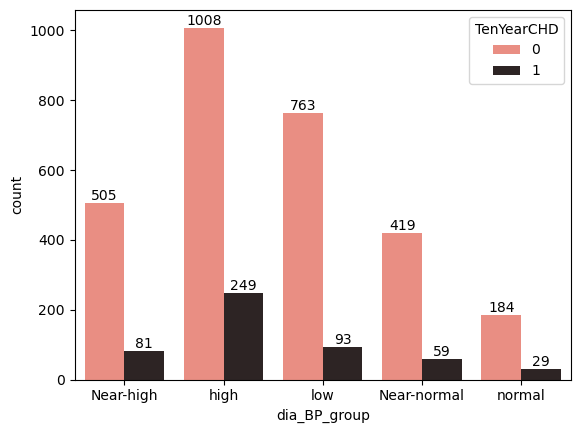

In [40]:
count_plot(df['dia_BP_group'])

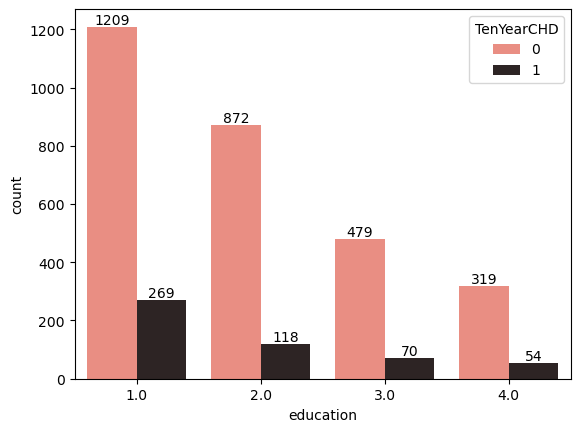

In [41]:
count_plot(df['education'])

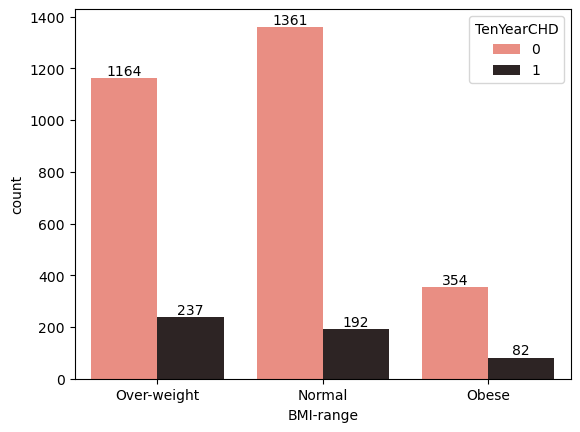

In [42]:
count_plot(df["BMI-range"])

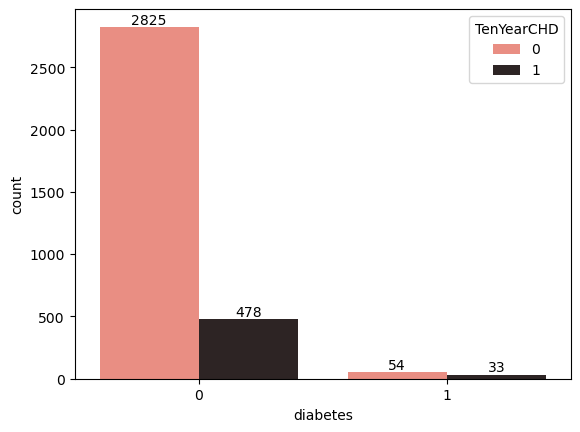

In [43]:
count_plot(df['diabetes'])

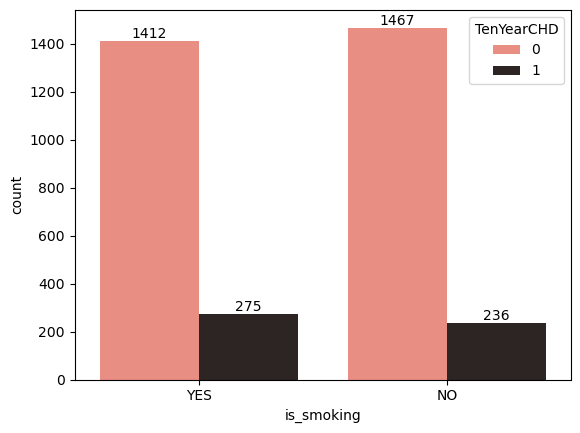

In [44]:
count_plot(df['is_smoking'])

# Plotting Pie Chart to Show Risk-%

In [45]:
def pie_chart(col):
    p=col.value_counts()
    plt.pie(p, labels=p.index, autopct='%.1f%%')
    plt.show()

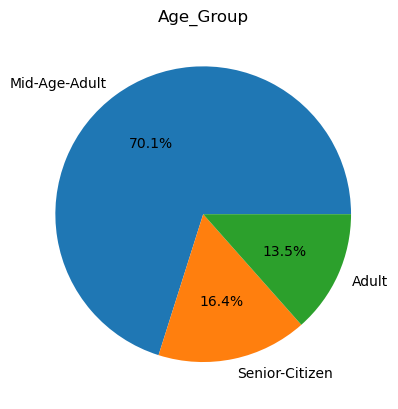

In [46]:
plt.title("Age_Group")
pie_chart(df['Age_group'])


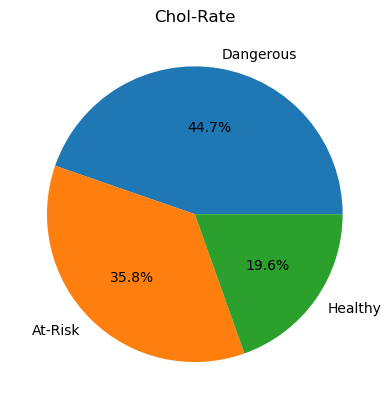

In [47]:
plt.title("Chol-Rate")
pie_chart(df['Chol-range'])

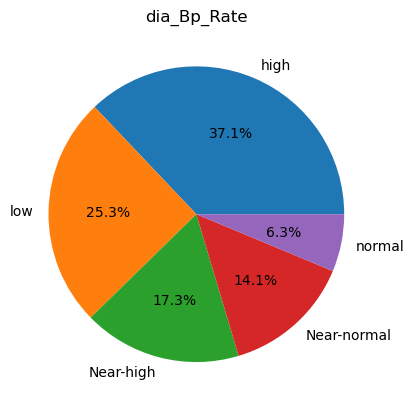

In [48]:
plt.title("dia_Bp_Rate")
pie_chart(df['dia_BP_group'])

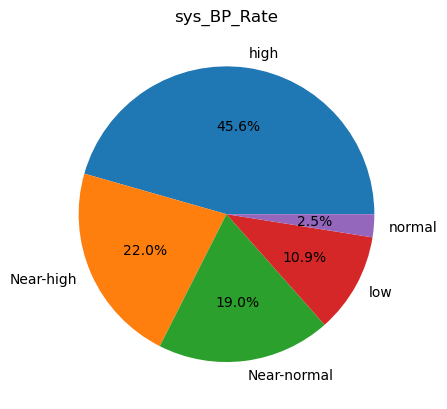

In [49]:
plt.title("sys_BP_Rate")
pie_chart(df['sys_BP_group'])

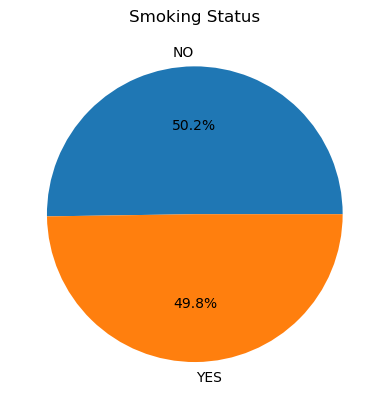

In [50]:
plt.title("Smoking Status")
pie_chart(df['is_smoking'])

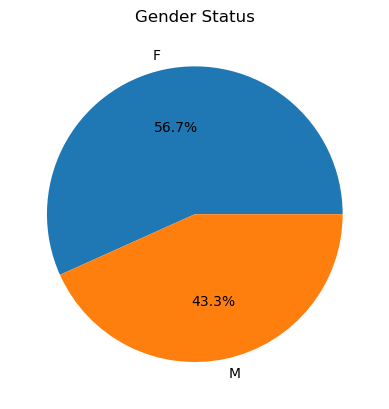

In [51]:
plt.title("Gender Status")
pie_chart(df['sex'])

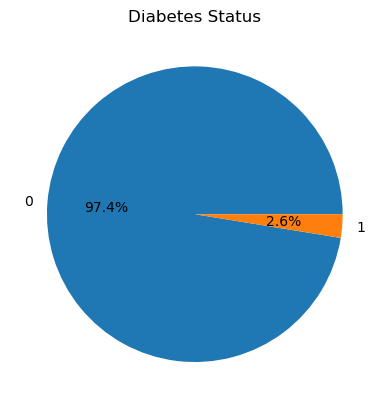

In [52]:
plt.title("Diabetes Status")
pie_chart(df['diabetes'])